In [1]:
import numpy as np
import torch
import torch.nn as nn
from typing import Iterable

from utils import onehot, seed_everything
from automatons import PatternMatchingAutomaton, Automaton
from models import RecursiveNeuralNetworkFromScratch, Model
from callbacks import Projection, RecursiveNeuralNetworkFromScratchSampleOutput

seed_everything(123)

2024-11-20 03:27:41.049968: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-20 03:27:41.062462: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-20 03:27:41.065893: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-20 03:27:41.076109: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-20 03:27:41.948930: W tensorflow/compiler/tf2

123

In [2]:
pattern = [0, 1, 1, 0]
patternon = PatternMatchingAutomaton(pattern)
end_of_sequence_token = patternon.tokens
end_of_sequence_token

2

In [3]:
def pattern_matching_data_generator():
  data = onehot([*list(patternon.generator), end_of_sequence_token], patternon.tokens+1)
  return data[:-1], data[1:]

In [4]:
RNN = RecursiveNeuralNetworkFromScratch(tokens = patternon.tokens+1, hidden_size=7) # account for the end of sequence token

In [5]:
history = list(RNN.fit(
	pattern_matching_data_generator,
	epochs=7000,
	callbacks=[RecursiveNeuralNetworkFromScratchSampleOutput(
		RNN, pattern, eos=patternon.tokens,
		init = lambda: pattern_matching_data_generator()[0][0]), Projection(patternon)
	],
))

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat in method wrapper_CUDA_addmv_)

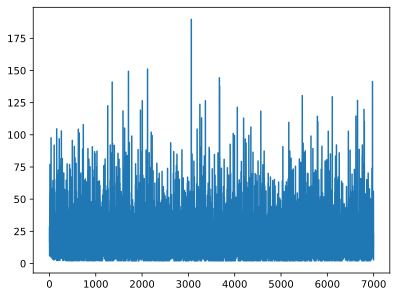

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history) #?